## **SNAP Jupyter demo notebook**
**Distributed-Scatterer InSAR time series — Phase Linking (SqueeSAR / EVD / EMI) + SBAS inversion**

In summary, this workflow contains:

- Background on PS vs DS InSAR, phase linking, and SBAS time-series inversion
- **Part 1**: phase-link a coregistered SLC stack (`PhaseLinking`) and inspect the temporal-coherence quality map
- **Part 1b** *(no SNAPHU needed)*: show the coherence gain over distributed scatterers — raw vs phase-linked interferogram
- **Part 2**: build a small-baseline interferogram network (`MultiMasterInSAR`)
- **Part 3**: unwrap each interferogram (SNAPHU, external)
- **Part 4**: invert the network to a per-epoch displacement time series + velocity (`SBASInversion`)

This is the modern DS-InSAR / SqueeSAR-class workflow (cf. MiaplPy, dolphin, MintPy) — now **native** in the Microwave Toolbox, with no export to external time-series tools.

Complexity: advanced

##### ***Requirements:***

- **Toolbox.** `PhaseLinking`, `MultiMasterInSAR` and `SBASInversion` ship with the **Microwave Toolbox in SNAP 14+**. Check with `gpt PhaseLinking -h`; if it prints *"Unknown operator"*, update the Microwave Toolbox (or build the current `sar-op-insar` into your SNAP install).
- **Input.** Part 1 runs out-of-the-box: a small (~250 MB) **coregistered 12-acquisition Sentinel-1 IW SLC stack over Mt Etna** (descending track 124, IW2, 6-day cadence, Jan–Mar 2021, cropped to ~10×10 km around the summit) downloads once and is cached. To use your own area, build a coregistered stack with the standard chain (`Apply-Orbit-File → TOPSAR-Split → Back-Geocoding → Enhanced-Spectral-Diversity` across all dates) and point `stack_product` at it.
- **SNAPHU.** Parts 3–4 (network unwrapping → SBAS) need [SNAPHU](https://web.stanford.edu/group/radar/softwareandlinks/sw/snaphu/) (no native Windows build → use WSL/Linux/macOS). **Parts 1–2 run without it.**

##### ***Some information on the Python environment:***

In [1]:
import os
import sys
print("Python version: " + sys.version)

import sysconfig
print("Location of esa_snappy package: " + sysconfig.get_paths()['purelib'] + os.sep + "esa_snappy")

Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Location of esa_snappy package: C:\Users\luis_\AppData\Local\Programs\Python\Python313\Lib\site-packages\esa_snappy


##### ***Import Python packages...***

In [2]:
import esa_snappy
from esa_snappy import ProductIO

import snapista
from snapista import Graph
from snapista import Operator

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

##### ***Convenience functions (decimation-safe readers + cached fetch):***

In [3]:
def _read_dec(band, target=1400):
    """Read a band downsampled to ~target px on the long side, in small row strips (avoids the
    'Cannot construct DataBuffer' that a full read of a large/virtual band triggers)."""
    w, h = band.getRasterWidth(), band.getRasterHeight()
    dec = max(1, int(max(w, h) / target)); cols = list(range(0, w, dec)); out = []
    for y in range(0, h, 48):
        bh = min(48, h - y)
        buf = np.zeros(w * bh, np.float32); band.readPixels(0, y, w, bh, buf)
        buf.shape = (bh, w); out.append(buf[::dec][:, cols])
    return np.vstack(out)

def plot_band(product, name, title=None, cmap='viridis', vmin=None, vmax=None):
    data = _read_dec(product.getBand(name))
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title or name); fig.colorbar(im, ax=ax)
    plt.show()

def coherence_band(product):
    """Mean of the first coherence band, decimated and masked at no-data."""
    cohN = next(b.getName() for b in product.getBands() if b.getName().lower().startswith('coh'))
    c = _read_dec(product.getBand(cohN))
    return cohN, np.ma.masked_where(c <= 0, c)

import urllib.request as _urlreq, zipfile as _zip, glob as _glob
def fetch_cached(url, dest_dir):
    """Download a public URL into dest_dir unless already present, unzip a .zip, return the path
    to open (manifest.safe / .dim). Cached for re-runs."""
    os.makedirs(dest_dir, exist_ok=True)
    fname = url.split('/')[-1]; stem = fname.rsplit('.', 1)[0]
    hits = _glob.glob(os.path.join(dest_dir, stem + '*', 'manifest.safe')) + _glob.glob(os.path.join(dest_dir, stem + '*.dim'))
    if hits:
        print('cached:', os.path.basename(hits[0])); return hits[0]
    local = os.path.join(dest_dir, fname)
    if not os.path.exists(local):
        print('downloading', fname, '...'); _urlreq.urlretrieve(url, local)
    if fname.lower().endswith('.zip'):
        with _zip.ZipFile(local) as z: z.extractall(dest_dir)
        hits = _glob.glob(os.path.join(dest_dir, stem + '*', 'manifest.safe')) + _glob.glob(os.path.join(dest_dir, stem + '*.dim'))
        return hits[0] if hits else local
    return local

def epoch_dates(product):
    """Sorted ddMMMyyyy epoch dates parsed from the stack's i_* band names."""
    import datetime, re
    ds = set()
    for b in product.getBands():
        m = re.search(r'_(\d{2}[A-Za-z]{3}\d{4})$', b.getName())
        if m: ds.add(m.group(1))
    return sorted(ds, key=lambda d: datetime.datetime.strptime(d, '%d%b%Y'))

def small_baseline_pairs(dates, max_step=2):
    """Connect each epoch to the next `max_step` epochs -> small-baseline network."""
    out = []
    for i in range(len(dates)):
        for j in range(i + 1, min(i + 1 + max_step, len(dates))):
            out.append(f'{dates[i]}-{dates[j]}')
    return out

---

### ***What is phase linking, and how do you use it?***

**The problem.** A repeat-pass interferogram between two SAR acquisitions carries the ground-motion signal in its phase — but over *natural* surfaces (soil, vegetation, lava, debris) the scattering changes between passes, so a single pair is **decorrelated** (noisy, low coherence). Classical **Persistent-Scatterer (PS)** InSAR sidesteps this by keeping only point-like targets (buildings, rocks, corner reflectors) and throwing the rest of the scene away.

**The idea.** **Distributed-Scatterer (DS)** processing instead *recovers* a usable phase history over those natural surfaces by **phase linking** (the SqueeSAR family). For each pixel it:

1. finds a set of **Statistically Homogeneous Pixels (SHPs)** — nearby pixels whose amplitudes pass a two-sample test (KS / AD), i.e. that look like the same kind of surface;
2. forms the **N×N complex sample coherence matrix** from those SHPs across all *N* acquisitions;
3. **jointly estimates one optimal phase per epoch** from all *N(N−1)/2* interferometric phases at once — far more robust than any single pair. SNAP offers two estimators: **EVD** (dominant eigenvector, fast) and **EMI** (lower bias at low coherence).

It also emits a **temporal coherence** band — a 0–1 goodness-of-fit score saying how well one consistent phase history explains the whole covariance matrix. That is your quality mask: keep pixels above ~0.6–0.7.

**Why it matters.** The phase-linked stack is a **drop-in** replacement for the coregistered stack in every downstream InSAR operator, and its distributed-scatterer pairs are dramatically more coherent (Part 1b shows the mean coherence roughly doubling here). That coherence gain is what makes a dense, scene-wide deformation time series possible — not just a sparse PS cloud.

**How to use it (this notebook).**
- **Part 1** runs `PhaseLinking` on a coregistered SLC stack. Key knobs: `windowAzimuth`/`windowRange` (SHP search window — bigger = more SHPs, more smoothing), `shpMin` (min SHPs to trust a pixel), `shpTest` (`KS`/`AD`/`TLog`), `estimator` (`EVD`/`EMI`), and `tempCohMin` (mask threshold). It writes a phase-linked stack + `tempCoh` + `numSHP` bands.
- **Part 1b** demonstrates the coherence gain (raw vs phase-linked), no unwrapping needed.
- **Parts 2–4** then take the linked stack through a small-baseline interferogram network → SNAPHU unwrapping → `SBASInversion` for a per-epoch displacement time series + velocity — the same end product as MiaplPy / dolphin / MintPy, but native in the Microwave Toolbox.

```text
coregistered SLC stack
        │  PhaseLinking            (DS phase estimation + temporal coherence)
        ▼
 phase-linked stack
        │  MultiMasterInSAR        (small-baseline interferogram network)
        ▼
 wrapped interferograms + coherence
        │  SnaphuExport → SNAPHU → SnaphuImport   (unwrap each pair; external)
        ▼
 unwrapped network
        │  SBASInversion           (per-epoch displacement + velocity)
        ▼
 deformation time series
```

---

### ***Configure input paths***

In [4]:
data_dir = os.path.join(os.getcwd(), 'data')
graphs_dir = os.path.join(os.getcwd(), 'graphs')
results_dir = os.path.join(os.getcwd(), 'results')
snaphu_dir = os.path.join(os.getcwd(), 'snaphu')
for d in (graphs_dir, results_dir, snaphu_dir):
    os.makedirs(d, exist_ok=True)

# Make the gpt subprocess emit UTF-8 console text (snapista decodes gpt stdout as UTF-8; on Windows
# gpt would otherwise emit cp1252 and snapista raises UnicodeDecodeError).
os.environ.setdefault('JAVA_TOOL_OPTIONS', '-Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8')

# --- Coregistered SLC stack (the input to PhaseLinking) ---
# A small (~250 MB) coregistered 12-acquisition Sentinel-1 IW SLC stack over Mt Etna downloads once and
# is cached locally. It is descending track 124, subswath IW2, 6-day cadence (Jan-Mar 2021), cropped to
# ~10x10 km around the summit. It was built with the standard TOPS chain across all 12 dates:
#   Apply-Orbit-File -> TOPSAR-Split(IW2) -> Back-Geocoding -> TOPSAR-Deburst -> Subset
# To use your own stack instead, set STACK_URL = '' and point stack_product at a local coregistered
# BEAM-DIMAP whose bands are i_<date>/q_<date> pairs (e.g. the output of Back-Geocoding + ESD).
STACK_URL = 'https://skywatch-public.s3.us-west-2.amazonaws.com/snap/data/S1/SLC/etna-ds-insar/etna_coreg_stack.zip'
if STACK_URL:
    stack_product = fetch_cached(STACK_URL, data_dir)
else:
    stack_product = os.path.join(data_dir, 'coreg_stack.dim')   # <-- your coregistered stack
print('stack:', stack_product)

# --- SNAPHU (Parts 3-4 only) ---
# Used natively if 'snaphu' is on PATH; on Windows it can also run through WSL (build it with the
# provided setup script - there is no native Windows binary). Parts 1-2 do not need SNAPHU.
SNAPHU_BIN = 'snaphu'                                    # native binary name / full path
SNAPHU_WSL = '~/snaphu-build/snaphu-v2.0.5/bin/snaphu'   # WSL binary (Windows; built by the setup script)
# macOS/Linux source-build fallback: setup_ds_insar.sh builds here when brew/apt are unavailable
# (and the binary isn't on PATH) -- e.g. a Mac without Homebrew.
SNAPHU_LOCAL = os.path.expanduser('~/snaphu-build/snaphu-v2.0.5/bin/snaphu')
import shutil, subprocess

def _detect_snaphu():
    """Return (mode, exe). mode: 'native' (on PATH), 'local' (macOS/Linux source build),
    'wsl' (Windows via WSL), or None."""
    exe = shutil.which(SNAPHU_BIN)
    if exe:
        return 'native', exe
    if os.path.isfile(SNAPHU_LOCAL) and os.access(SNAPHU_LOCAL, os.X_OK):
        return 'local', SNAPHU_LOCAL                       # macOS/Linux source build (no brew/apt)
    if os.name == 'nt':
        try:
            r = subprocess.run(['wsl', '-e', 'bash', '-lc', f'test -x {SNAPHU_WSL} && echo ok'],
                               capture_output=True, text=True, timeout=30)
            if 'ok' in r.stdout:
                return 'wsl', SNAPHU_WSL
        except Exception:
            pass
    return None, None

snaphu_mode, snaphu_exe = _detect_snaphu()   # ('native'|'local'|'wsl'|None, path|None)
run_snaphu = snaphu_mode is not None
print('snaphu:', snaphu_mode or 'not found (Parts 3-4 will be skipped)')

def _win_to_wsl(p):
    """C:\\a\\b -> /mnt/c/a/b  (deterministic; avoids wslpath mangling backslashes through wsl.exe)."""
    p = os.path.abspath(p)
    return '/mnt/' + p[0].lower() + p[2:].replace('\\', '/')

def run_snaphu_in(folder, args):
    """Run snaphu inside `folder` with list `args`. WSL on Windows; the resolved native/local
    binary (snaphu_exe) otherwise."""
    if snaphu_mode == 'wsl':
        cmd = f"cd '{_win_to_wsl(folder)}' && {SNAPHU_WSL} " + ' '.join(args)
        return subprocess.run(['wsl', '-e', 'bash', '-lc', cmd], capture_output=True, text=True)
    return subprocess.run([snaphu_exe, *args], cwd=folder, capture_output=True, text=True)

cached: etna_coreg_stack.dim
stack: E:\ESA\snap-jupyter-notebooks\resources\jupyter_notebooks\data\etna_coreg_stack.dim


snaphu: wsl


---
## ***Part 1 — Phase Linking (DS-InSAR)***
---

`PhaseLinking` reads the coregistered stack, selects SHPs in a search window, forms the per-pixel
coherence matrix, and writes a phase-linked stack plus a temporal-coherence band. Defaults below use
the EVD estimator and the KS SHP test; switch `estimator='EMI'` for lower bias at low coherence.

In [5]:
g_pl = Graph()
g_pl.add_node(operator=Operator('Read', file=stack_product), node_id='Read')
g_pl.add_node(operator=Operator('PhaseLinking',
                                windowAzimuth='15',       # SHP search window (15 x 15 ~ 166 SHPs here)
                                windowRange='15',
                                shpTest='KS',
                                shpMin='20',
                                estimator='EVD',          # or 'EMI' for lower bias at low coherence
                                tempCohMin='0.5',
                                outputTempCoherence='true',
                                outputShpCount='true'),
              node_id='PhaseLinking', source='Read')

linked_out = os.path.join(results_dir, 'ds_insar_phaselinked.dim')
g_pl.add_node(operator=Operator('Write', file=linked_out, formatName='BEAM-DIMAP'),
              node_id='Write', source='PhaseLinking')

g_pl.save_graph(os.path.join(graphs_dir, 'ds_insar_phaselinking.xml'))
g_pl.run()

Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
.10%..21%.31%.42%.52%.63%.74%.84%. done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8 -Djava.io.tmpdir=E:\snap_tmp
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
[main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
[main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
[main] INFO hdf.hdf5lib.H5 - HDF5 library: 
[main] INFO hdf.hdf5lib.H5 -  successfully loaded.
Processing finished successfully.


0

##### ***Inspect the temporal-coherence quality map:***

Bands: ['i_pl_IW2_VV_ref_04Jan2021', 'q_pl_IW2_VV_ref_04Jan2021', 'Intensity_pl_IW2_VV_ref_04Jan2021', 'Phase_pl_IW2_VV_ref_04Jan2021', 'i_pl_IW2_VV_sec1_10Jan2021', 'q_pl_IW2_VV_sec1_10Jan2021', 'Intensity_pl_IW2_VV_sec1_10Jan2021', 'Phase_pl_IW2_VV_sec1_10Jan2021', 'i_pl_IW2_VV_sec2_16Jan2021', 'q_pl_IW2_VV_sec2_16Jan2021', 'Intensity_pl_IW2_VV_sec2_16Jan2021', 'Phase_pl_IW2_VV_sec2_16Jan2021'] ...


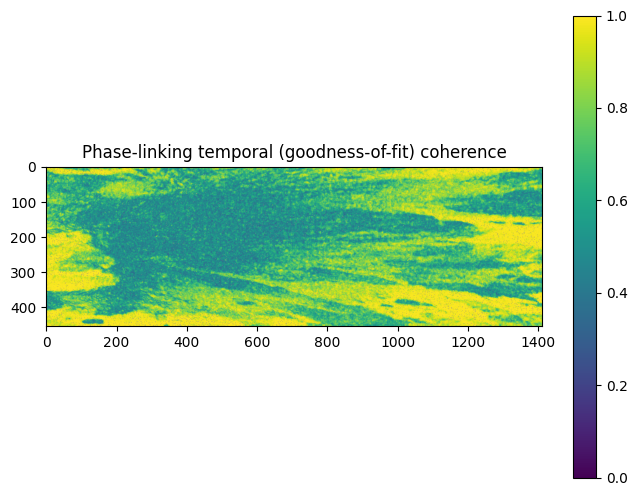

Pixels with temporal coherence > 0.6 are reliable DS targets.


In [6]:
p_linked = ProductIO.readProduct(linked_out)
print('Bands:', [b.getName() for b in p_linked.getBands()][:12], '...')
tempcoh = next(b.getName() for b in p_linked.getBands() if b.getName().lower().startswith('tempcoh'))
plot_band(p_linked, tempcoh, title='Phase-linking temporal (goodness-of-fit) coherence', cmap='viridis', vmin=0, vmax=1)
print('Pixels with temporal coherence > 0.6 are reliable DS targets.')

---

### ***Part 1b — the DS coherence gain (no SNAPHU needed)***

The whole point of phase linking: distributed-scatterer interferograms become *much* more coherent. We
form one interferogram + coherence from the **raw** stack and from the **phase-linked** stack and compare.
On this Etna stack the mean coherence roughly **doubles** (≈ 0.33 → ≈ 0.62, a ~+88 % gain) — that jump is
what turns noisy natural-surface pixels into usable time-series targets.

Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
.10%..21%.31%.42%.52%.63%.74%.84%. done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8 -Djava.io.tmpdir=E:\snap_tmp
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
-- org.jblas INFO Starting temp DLL cleanup task.
-- org.jblas INFO Deleted 4 unused temp DLL libraries from E:\snap_tmp
Processing finished successfully.


Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
.10%..21%.31%.42%.52%.63%.74%.84%. done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8 -Djava.io.tmpdir=E:\snap_tmp
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
-- org.jblas INFO Starting temp DLL cleanup task.
-- org.jblas INFO Deleted 4 unused temp DLL libraries from E:\snap_tmp
Processing finished successfully.


mean coherence  raw=0.33   phase-linked=0.62


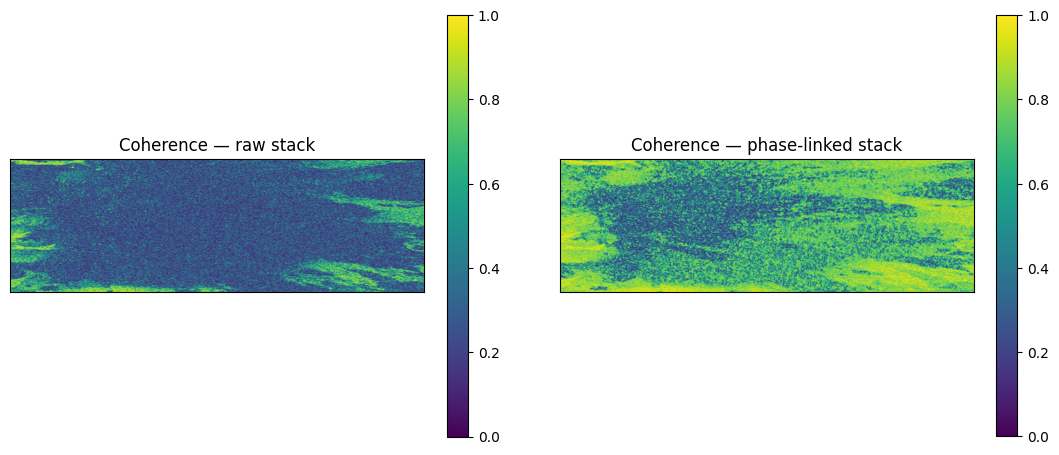

In [7]:
def first_coherence(product_path, tag):
    g = Graph()
    g.add_node(operator=Operator('Read', file=product_path), node_id='Read')
    # 3 az x 10 rg ~ a roughly square ground window at S1 IW pixel spacing (~14 m az, ~2.3 m rg).
    g.add_node(operator=Operator('Interferogram', subtractFlatEarthPhase='true',
                                 includeCoherence='true', cohWinAz='3', cohWinRg='10'),
               node_id='Ifg', source='Read')
    out = os.path.join(results_dir, f'ds_insar_coh_{tag}.dim')
    g.add_node(operator=Operator('Write', file=out, formatName='BEAM-DIMAP'), node_id='Write', source='Ifg')
    g.run()
    return ProductIO.readProduct(out)

p_raw_ifg = first_coherence(stack_product, 'raw')
p_lnk_ifg = first_coherence(linked_out, 'linked')
nraw, craw = coherence_band(p_raw_ifg)
nlnk, clnk = coherence_band(p_lnk_ifg)
print('mean coherence  raw=%.2f   phase-linked=%.2f' % (float(np.ma.mean(craw)), float(np.ma.mean(clnk))))

fig, axs = plt.subplots(1, 2, figsize=(13, 6))
for ax, c, t in [(axs[0], craw, 'raw stack'), (axs[1], clnk, 'phase-linked stack')]:
    im = ax.imshow(c, cmap='viridis', vmin=0, vmax=1); ax.set_title('Coherence — ' + t); fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([]); ax.set_yticks([])
plt.show()
for p in (p_raw_ifg, p_lnk_ifg): p.dispose()

##### ***...and the interferogram fringes:***

Coherence tells you *where* the phase is reliable; the wrapped **phase** is the signal itself. Below we
show the same first-pair interferogram from the **raw** stack vs the **phase-linked** stack. Over the
volcano flanks the raw fringes are speckled noise, while the phase-linked fringes are smooth and
continuous — i.e. now suitable for unwrapping.

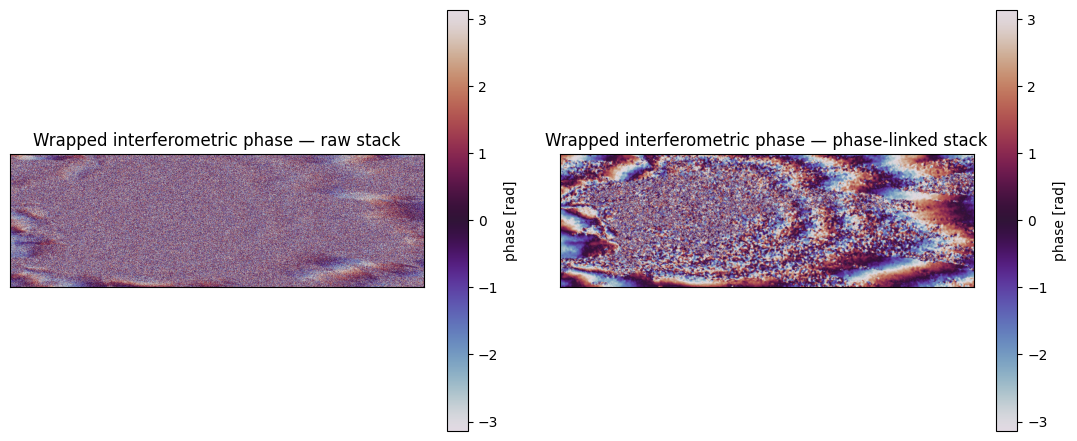

Raw fringes are speckled/incoherent over the volcano flanks; phase linking yields smooth, continuous fringes there - the same scene, now unwrappable.


In [8]:
def wrapped_phase(product_path):
    """Wrapped interferometric phase = atan2(q_ifg, i_ifg), decimated, from an Interferogram product."""
    p = ProductIO.readProduct(product_path)
    iN = next(b.getName() for b in p.getBands() if b.getName().lower().startswith('i_ifg'))
    qN = next(b.getName() for b in p.getBands() if b.getName().lower().startswith('q_ifg'))
    ph = np.arctan2(_read_dec(p.getBand(qN)), _read_dec(p.getBand(iN)))
    p.dispose()
    return ph

ph_raw = wrapped_phase(os.path.join(results_dir, 'ds_insar_coh_raw.dim'))
ph_lnk = wrapped_phase(os.path.join(results_dir, 'ds_insar_coh_linked.dim'))

fig, axs = plt.subplots(1, 2, figsize=(13, 6))
for ax, ph, t in [(axs[0], ph_raw, 'raw stack'), (axs[1], ph_lnk, 'phase-linked stack')]:
    im = ax.imshow(ph, cmap='twilight', vmin=-np.pi, vmax=np.pi)
    ax.set_title('Wrapped interferometric phase — ' + t)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, label='phase [rad]')
plt.show()
print('Raw fringes are speckled/incoherent over the volcano flanks; phase linking yields smooth, '
      'continuous fringes there - the same scene, now unwrappable.')

---
## ***Part 2 — Small-baseline interferogram network***
---

`MultiMasterInSAR` builds interferograms (phase + coherence) for a chosen set of date pairs from the
phase-linked stack. We connect each epoch to its **next neighbour** (consecutive 6-day pairs) for a
minimal small-baseline network — raise `max_step` for a denser, more redundant network.

In [9]:
dates = epoch_dates(p_linked)
# Consecutive (6-day) pairs -> a minimal connected small-baseline network (11 pairs for 12 epochs).
# Use max_step=2 to add redundancy (denser network, more robust SBAS) at the cost of ~2x the SNAPHU time.
pairs = small_baseline_pairs(dates, max_step=1)
print(f'{len(dates)} epochs -> {len(pairs)} small-baseline pairs')
print('first pairs:', pairs[:5])

g_net = Graph()
g_net.add_node(operator=Operator('Read', file=linked_out), node_id='Read')
# MultiMasterInSAR requires an elevation band on the input (for the reference/topographic phase).
g_net.add_node(operator=Operator('AddElevation',
                                 demName='Copernicus 30m Global DEM',
                                 demResamplingMethod='BICUBIC_INTERPOLATION',
                                 elevationBandName='elevation'),
               node_id='Elevation', source='Read')
g_net.add_node(operator=Operator('MultiMasterInSAR',
                                 pairs=','.join(pairs),
                                 cohWindowAz='3',
                                 cohWindowRg='10'),
               node_id='Network', source='Elevation')
network_out = os.path.join(results_dir, 'ds_insar_network.dim')
g_net.add_node(operator=Operator('Write', file=network_out, formatName='BEAM-DIMAP'),
               node_id='Write', source='Network')
g_net.save_graph(os.path.join(graphs_dir, 'ds_insar_network.xml'))
g_net.run()
p_linked.dispose()

12 epochs -> 11 small-baseline pairs
first pairs: ['04Jan2021-10Jan2021', '10Jan2021-16Jan2021', '16Jan2021-22Jan2021', '22Jan2021-28Jan2021', '28Jan2021-03Feb2021']
Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
.10%...25%.35%.45%.55%.65%.75%.85%. done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8 -Djava.io.tmpdir=E:\snap_tmp
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
[main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
[main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
[main] INFO hdf.hdf5lib.H5 - HDF5 library: 
[main] INFO hdf.hdf5lib.H5 -  successfully loaded.
-- org.jblas INFO Starting temp DLL cleanup task.
-- org.jblas INFO Deleted 4 unused temp DLL libraries from E:\snap_tmp
Processing finished successfully.


---
## ***Part 3 — Unwrap the network (SNAPHU, external)***
---

Each wrapped interferogram must be phase-unwrapped before inversion. `SnaphuExport` writes **one folder**
holding the wrapped phase + coherence for every pair and one `<master>_<slave>snaphu.conf` per pair
(its header carries the exact `snaphu` command line). We run `snaphu` once per pair, then chain
`SnaphuImport` (which takes exactly one wrapped + one unwrapped product at a time) to fold every
unwrapped pair back into the network as an `UnwPhase_*` band.

SNAPHU has no native Windows build, so the config cell auto-detects it: a native `snaphu` on `PATH`, or
a **WSL** build (made by the setup script). If neither is found, Parts 3–4 are **skipped automatically**
and Parts 1–2 still run.

In [10]:
if not run_snaphu:
    print("snaphu not available - skipping Parts 3-4 (build it with the setup script's WSL step, "
          "or put a native 'snaphu' on PATH).")
    unwrapped_network = None
else:
    import re, glob
    # 1) Export the network. SnaphuExport writes ONE folder (named after the product) containing the
    #    wrapped phase + coherence for every pair, plus one <master>_<slave>snaphu.conf per pair.
    g_exp = Graph()
    g_exp.add_node(operator=Operator('Read', file=network_out), node_id='Read')
    g_exp.add_node(operator=Operator('SnaphuExport', targetFolder=snaphu_dir,
                                     statCostMode='DEFO', initMethod='MCF',
                                     numberOfTileRows='1', numberOfTileCols='1',
                                     numberOfProcessors='4', rowOverlap='0', colOverlap='0',
                                     tileCostThreshold='500'),
                   node_id='SnaphuExport', source='Read')
    g_exp.save_graph(os.path.join(graphs_dir, 'ds_insar_snaphu_export.xml'))
    g_exp.run()
    export_dir = next(d for d in glob.glob(os.path.join(snaphu_dir, '*')) if os.path.isdir(d))

    # 2) Unwrap each pair. Every *snaphu.conf header carries the exact command line
    #    'snaphu -f <conf> <phase.img> <linelength>'. (Skip the generic 'snaphu.conf' SNAP also writes.)
    confs = sorted(c for c in glob.glob(os.path.join(export_dir, '*snaphu.conf'))
                   if os.path.basename(c) != 'snaphu.conf')
    print(f'unwrapping {len(confs)} interferograms with snaphu ({snaphu_mode}) ...')
    for c in confs:
        m = re.search(r'^#\s*snaphu\s+(.+)$', open(c).read(), re.MULTILINE)
        if not m:
            raise RuntimeError(f'no snaphu command in {os.path.basename(c)}')
        r = run_snaphu_in(export_dir, m.group(1).split())
        if r.returncode != 0:
            raise RuntimeError(f'snaphu failed on {os.path.basename(c)}: {r.stderr[-400:]}')
    print('  done; UnwPhase files:', len(glob.glob(os.path.join(export_dir, 'UnwPhase*.img'))))

    # 3) Import the unwrapped phase back. SnaphuImport takes EXACTLY two products (wrapped + one
    #    unwrapped), so we chain it: each stage adds one pair's UnwPhase band to the running product.
    unw_hdrs = sorted(glob.glob(os.path.join(export_dir, 'UnwPhase*.hdr')))
    g_imp = Graph()
    g_imp.add_node(operator=Operator('Read', file=network_out), node_id='Wrapped')
    prev = 'Wrapped'
    for i, h in enumerate(unw_hdrs):
        g_imp.add_node(operator=Operator('Read', file=h), node_id=f'U{i}')
        g_imp.add_node(operator=Operator('SnaphuImport', doNotKeepWrapped='false'),
                       node_id=f'Imp{i}', source=[prev, f'U{i}'])
        prev = f'Imp{i}'
    unwrapped_network = os.path.join(results_dir, 'ds_insar_unwrapped.dim')
    g_imp.add_node(operator=Operator('Write', file=unwrapped_network, formatName='BEAM-DIMAP'),
                   node_id='Write', source=prev)
    g_imp.save_graph(os.path.join(graphs_dir, 'ds_insar_snaphu_import.xml'))
    g_imp.run()
    print('unwrapped network ->', unwrapped_network)

Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
.11%.22%.33%.45%.56%.67%.78%.90% done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8 -Djava.io.tmpdir=E:\snap_tmp
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
[main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
[main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
[main] INFO hdf.hdf5lib.H5 - HDF5 library: 
[main] INFO hdf.hdf5lib.H5 -  successfully loaded.
-- org.jblas INFO Starting temp DLL cleanup task.
-- org.jblas INFO Deleted 4 unused temp DLL libraries from E:\snap_tmp
Processing finished successfully.
unwrapping 11 interferograms with snaphu (wsl) ...


  done; UnwPhase files: 11
Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
....11%...21%....33%....44%...54%....66%....78%....90% done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8 -Djava.io.tmpdir=E:\snap_tmp
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
[main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
[main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
[main] INFO hdf.hdf5lib.H5 - HDF5 library: 
[main] INFO hdf.hdf5lib.H5 -  successfully loaded.
Processing finished successfully.
unwrapped network -> E:\ESA\snap-jupyter-notebooks\resources\jupyter_notebooks\results\ds_insar_unwrapped.dim


---
## ***Part 4 — SBAS inversion: displacement time series + velocity***
---

`SBASInversion` takes the unwrapped small-baseline network and solves a least-squares system for the
per-epoch phase relative to a reference epoch, converts to line-of-sight **displacement (mm)**, and fits
an average **velocity (mm/yr)** plus a `velocity_uncertainty` and `temporal_coherence` diagnostic.

> **Read this before interpreting the numbers.** This compact demo (3 months, 6-day sampling, one
> subswath, ~10×10 km) runs the pipeline end-to-end but uses *minimal* processing — automatic reference,
> **no atmospheric-phase correction**, and a minimal consecutive-pair network. The resulting velocity and
> time series are therefore **dominated by atmospheric phase and residual unwrapping noise** (cm-scale,
> spatially correlated), *not* a calibrated Etna deformation signal. Treat the plots below as examples of
> the **product types** SBAS yields. A real survey adds APS correction (e.g. GACOS), a stable reference
> point, a longer/denser redundant network, and outlier control.

Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
.10%..21%.31%.42%.52%.63%.74%.84%. done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8 -Djava.io.tmpdir=E:\snap_tmp
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
[main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
[main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
[main] INFO hdf.hdf5lib.H5 - HDF5 library: 
[main] INFO hdf.hdf5lib.H5 -  successfully loaded.
Processing finished successfully.
SBAS bands: ['phase_04Jan2021', 'displacement_04Jan2021', 'phase_10Jan2021', 'displacement_10Jan2021', 'phase_16Jan2021', 'displacement_16Jan2021', 'phase_22Jan2021', 'displacement_22Jan2021', 'phase_28Jan2021', 'displacement_28Jan2021', 'phase_03Feb2021', 'displacement_03Feb2021', 'phase

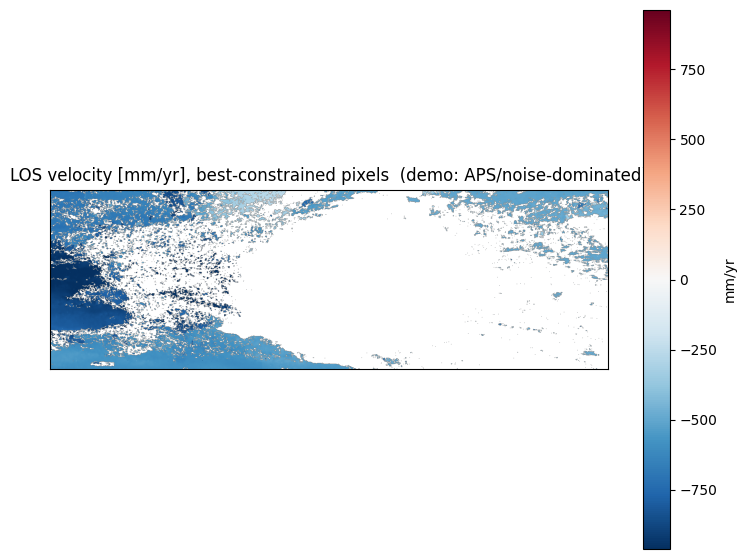

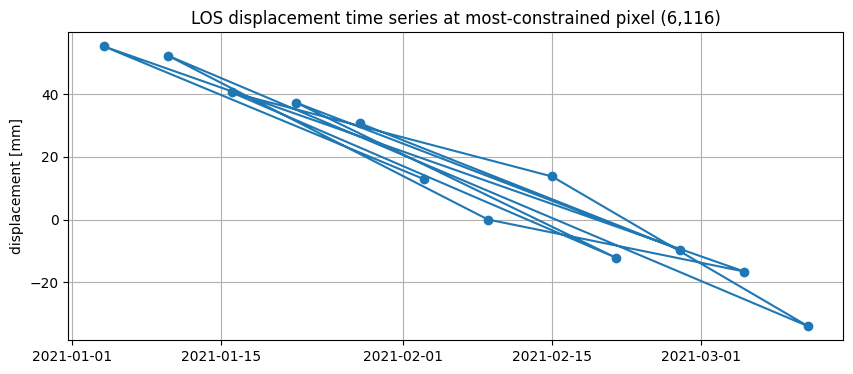

In [11]:
if run_snaphu and unwrapped_network:
    g_sbas = Graph()
    g_sbas.add_node(operator=Operator('Read', file=unwrapped_network), node_id='Read')
    g_sbas.add_node(operator=Operator('SBASInversion',
                                      coherenceMin='0.3',
                                      outputVelocity='true',
                                      outputResiduals='false'),
                    node_id='SBAS', source='Read')
    sbas_out = os.path.join(results_dir, 'ds_insar_sbas.dim')
    g_sbas.add_node(operator=Operator('Write', file=sbas_out, formatName='BEAM-DIMAP'),
                    node_id='Write', source='SBAS')
    g_sbas.save_graph(os.path.join(graphs_dir, 'ds_insar_sbas.xml'))
    g_sbas.run()

    p_sbas = ProductIO.readProduct(sbas_out)
    print('SBAS bands:', [b.getName() for b in p_sbas.getBands()])
    velN = next(b.getName() for b in p_sbas.getBands() if b.getName().lower().startswith('velocity')
                and 'uncert' not in b.getName().lower())
    uncN = next((b.getName() for b in p_sbas.getBands() if 'uncert' in b.getName().lower()), None)
    vel = _read_dec(p_sbas.getBand(velN))
    unc = _read_dec(p_sbas.getBand(uncN)) if uncN else np.full_like(vel, np.nan)

    # Keep the best-constrained pixels (lowest velocity uncertainty). NOTE: on this short demo the
    # field is atmosphere/noise-dominated - see the caveat above; this is a product example, not signal.
    valid = np.isfinite(vel) & np.isfinite(unc)
    thr = np.nanpercentile(unc[valid], 40) if valid.any() else np.inf
    good = valid & (unc <= thr)
    vel_m = np.where(good, vel, np.nan)

    vmax = np.nanpercentile(np.abs(vel_m), 95)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(vel_m, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title('LOS velocity [mm/yr], best-constrained pixels  (demo: APS/noise-dominated)')
    fig.colorbar(im, ax=ax, label='mm/yr'); ax.set_xticks([]); ax.set_yticks([])
    plt.show()

    # Displacement time series at the most-constrained pixel (lowest velocity uncertainty)
    disp_bands = sorted([b.getName() for b in p_sbas.getBands() if b.getName().lower().startswith('displacement_')])
    if disp_bands and good.any():
        u = np.where(good, unc, np.nan)
        yx = np.unravel_index(np.nanargmin(u), u.shape)
        full_w = p_sbas.getBand(velN).getRasterWidth(); full_h = p_sbas.getBand(velN).getRasterHeight()
        dec = max(1, int(max(full_w, full_h) / 1400))
        px, py = int(yx[1] * dec), int(yx[0] * dec)   # plain Python ints (jpy has no numpy-int overload)
        series = []
        for n in disp_bands:
            buf = np.zeros(1, np.float32); p_sbas.getBand(n).readPixels(px, py, 1, 1, buf); series.append(float(buf[0]))
        import datetime
        t = [datetime.datetime.strptime(n.split('_')[-1], '%d%b%Y') for n in disp_bands]
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(t, series, 'o-')   # displacement band is already in mm
        ax.set_title(f'LOS displacement time series at most-constrained pixel ({px},{py})')
        ax.set_ylabel('displacement [mm]'); ax.grid(True)
        plt.show()
    p_sbas.dispose()
else:
    print('Parts 3-4 skipped (no SNAPHU / no unwrapped network).')

---

### ***Summary***

What have we learnt in this notebook?

- **Phase linking** (`PhaseLinking`, SqueeSAR / EVD / EMI) turns a coregistered SLC stack into a phase-linked stack where **distributed scatterers** become usable, with a temporal-coherence quality band for masking. On the Etna stack the temporal coherence is high (mean ≈ 0.84) with ~166 SHPs per 15×15 window.
- The phase-linked stack is a **drop-in** input to the interferogram operators: DS pairs become markedly more coherent — here the mean coherence roughly **doubles** (≈ 0.33 → ≈ 0.62, Part 1b). That gain is what makes DS time series possible.
- **`MultiMasterInSAR`** builds a small-baseline interferogram network from the linked stack (add an `elevation` band first with `AddElevation`).
- After unwrapping (SNAPHU, per pair), **`SBASInversion`** inverts the network to a **per-epoch displacement time series + velocity map** — natively in SNAP, no export to StaMPS/MintPy.
- This is the modern DS-InSAR pipeline (cf. MiaplPy / dolphin / MintPy) end-to-end in the Microwave Toolbox.